# QC extracted voltage data from `extractDendrites_new`

This notebook opens the lightweight MATLAB summary file and the paired HDF5 trace file produced by `extractDendrites_new`, then runs quick sanity checks:

- confirm extraction metadata and HDF5 structure
- inspect trial dataset sizes
- compute per-ROI NaN fractions and robust signal ranges
- plot example traces
- plot a z-scored trial heatmap
- optionally show reference/mask images if the MATLAB summary can be parsed

The HDF5 trace file is the source of truth for the extracted voltage traces. The MATLAB summary is used for metadata, ROI masks, reference images, and the path to the HDF5 file.


In [53]:
from pathlib import Path
import re
import warnings

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import scipy.io as sio
except Exception:
    sio = None

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))


In [51]:
%matplotlib notebook

## 1. Point this notebook at an extraction output

Set `summary_path` to the `dendriticVoltageSummary-*.mat` file. If `h5_path` is left as `None`, the notebook will try to find the paired HDF5 file from the summary metadata or by searching the same folder.


In [2]:
# Edit this path for your dataset.
summary_path = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260420-193104.mat")

# Optional: set explicitly if the notebook cannot find it from the summary.
h5_path = None

assert summary_path.exists(), f"Summary file not found: {summary_path}"
summary_path


WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/ASAP7/826031/826031_2026-01-30_15-04-02/slap2/dynamic_data/dendriticVoltageExtraction/dendriticVoltageSummary-260420-193104.mat')

## 2. Helper functions

These utilities try to load the MATLAB summary file with `scipy.io.loadmat` first. Since your summary is likely saved with `-v7.3`, it may require `mat73` or `hdf5storage` in your local Python environment. If the summary cannot be fully parsed, the notebook will still QC the HDF5 traces directly.


In [28]:
def _mat_struct_to_dict(obj):
    """Recursively convert scipy.io MATLAB structs into Python dicts/lists."""
    if hasattr(obj, "_fieldnames"):
        return {name: _mat_struct_to_dict(getattr(obj, name)) for name in obj._fieldnames}
    if isinstance(obj, np.ndarray):
        if obj.dtype == object:
            if obj.shape == ():
                return _mat_struct_to_dict(obj.item())
            return [_mat_struct_to_dict(x) for x in obj.ravel()]
        return obj
    return obj


def _decode_matlab_chars(x):
    """Decode common MATLAB char/string representations."""
    if isinstance(x, str):
        return x
    if isinstance(x, bytes):
        return x.decode(errors="ignore")
    if isinstance(x, np.ndarray):
        arr = np.asarray(x)
        if arr.dtype.kind in {"U", "S"}:
            return "".join(arr.ravel().astype(str))
        if arr.dtype.kind in {"u", "i"}:
            vals = arr.ravel()
            # MATLAB v7.3 chars are often uint16 code units.
            try:
                return "".join(chr(int(v)) for v in vals if int(v) != 0)
            except Exception:
                return x
    return x


def load_mat_summary(path: Path):
    """Load summary .mat if possible. Returns (summary_dict_or_None, loader_name)."""
    path = Path(path)

    # First try scipy for non-v7.3 .mat files.
    if sio is not None:
        try:
            data = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
            if "summary" in data:
                return _mat_struct_to_dict(data["summary"]), "scipy.io.loadmat"
        except NotImplementedError:
            pass
        except Exception as exc:
            warnings.warn(f"scipy.io.loadmat failed: {exc}")

    # Try mat73, which is often the easiest way to read MATLAB -v7.3 structs.
    try:
        import mat73
        data = mat73.loadmat(path)
        if "summary" in data:
            return data["summary"], "mat73.loadmat"
    except Exception as exc:
        warnings.warn(
            "Could not load full MATLAB v7.3 summary with mat73. "
            "This is okay for HDF5 trace QC. Install mat73 if you want masks/ref images. "
            f"Error: {exc}"
        )

    return None, "unavailable"


def find_h5_path(summary_path: Path, summary=None, explicit_h5_path=None):
    """Find paired dendriticVoltageTraces-*.h5 file."""
    if explicit_h5_path is not None:
        explicit_h5_path = Path(explicit_h5_path)
        if explicit_h5_path.exists():
            return explicit_h5_path

    if isinstance(summary, dict):
        maybe = summary.get("outputH5", None)
        if maybe is not None:
            maybe = _decode_matlab_chars(maybe)
            maybe = Path(str(maybe))
            if maybe.exists():
                return maybe

    # Fallback: search the summary folder for likely HDF5 outputs.
    candidates = sorted(
        summary_path.parent.glob("dendriticVoltageTraces-*.h5"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    if not candidates:
        candidates = sorted(summary_path.parent.glob("*.h5"), key=lambda p: p.stat().st_mtime, reverse=True)

    assert candidates, f"Could not find HDF5 trace file near {summary_path}"
    return candidates[0]


def walk_h5_datasets(h5_obj, prefix=""):
    """Return all dataset paths in an HDF5 file/group."""
    paths = []
    for key, value in h5_obj.items():
        path = f"{prefix}/{key}"
        if isinstance(value, h5py.Dataset):
            paths.append(path)
        elif isinstance(value, h5py.Group):
            paths.extend(walk_h5_datasets(value, path))
    return paths


def trial_dataset_paths(h5_path: Path):
    """Return sorted /traces/trial_XXXX datasets."""
    with h5py.File(h5_path, "r") as f:
        paths = walk_h5_datasets(f)
    trials = [p for p in paths if re.match(r"^/traces/trial_\d{4}$", p)]
    return sorted(trials)


def continuous_dataset_paths(h5_path: Path):
    """Return sorted continuous DMD datasets, if present."""
    with h5py.File(h5_path, "r") as f:
        paths = walk_h5_datasets(f)
    cont = [p for p in paths if re.match(r"^/traces/continuous/DMD\d+$", p)]
    return sorted(cont)


def dataset_shape_table(h5_path: Path, paths):
    """Build a table of HDF5 dataset shapes and selected attributes."""
    rows = []
    with h5py.File(h5_path, "r") as f:
        for p in paths:
            d = f[p]
            row = {
                "dataset": p,
                "n_lines": int(d.shape[0]) if len(d.shape) >= 1 else np.nan,
                "n_rois": int(d.shape[1]) if len(d.shape) >= 2 else np.nan,
                "dtype": str(d.dtype),
            }
            for attr in ["trialIdx", "dmdIdx", "description"]:
                if attr in d.attrs:
                    row[attr] = d.attrs[attr]
            rows.append(row)
    return pd.DataFrame(rows)


def read_h5_dataset(h5_path: Path, dataset_path: str):
    """Read one HDF5 dataset as a NumPy array."""
    with h5py.File(h5_path, "r") as f:
        arr = f[dataset_path][...]
    return np.asarray(arr).T


def robust_range(x, axis=0, lo=1, hi=99):
    return np.nanpercentile(x, hi, axis=axis) - np.nanpercentile(x, lo, axis=axis)


def zscore_by_column(x):
    mu = np.nanmean(x, axis=0, keepdims=True)
    sd = np.nanstd(x, axis=0, keepdims=True)
    sd[sd == 0] = np.nan
    return (x - mu) / sd


def downsample_rows_for_plot(x, max_points=20_000):
    """Return row-downsampled matrix and stride for plotting."""
    if x.shape[0] <= max_points:
        return x, 1
    stride = int(np.ceil(x.shape[0] / max_points))
    return x[::stride, :], stride


def get_summary_value(summary, key, default=None):
    if isinstance(summary, dict):
        return summary.get(key, default)
    return default


def get_cell_item(x, idx):
    """Best-effort cell/list indexing for MATLAB cell arrays loaded into Python."""
    if x is None:
        return None
    if isinstance(x, (list, tuple)):
        return x[idx]
    if isinstance(x, np.ndarray):
        if x.dtype == object:
            return x.ravel()[idx]
        if x.ndim >= 3:
            return x[..., idx]
    return None


## 3. Load summary metadata and locate the HDF5 traces


In [4]:
summary, summary_loader = load_mat_summary(summary_path)
h5_path = find_h5_path(summary_path, summary=summary, explicit_h5_path=h5_path)

print(f"Summary path: {summary_path}")
print(f"Summary loader: {summary_loader}")
print(f"HDF5 path:    {h5_path}")

if isinstance(summary, dict):
    for key in ["createdAt", "outputMode", "storageMode", "nDMDs", "nTrials", "nTotalROIs", "complete"]:
        value = get_summary_value(summary, key, None)
        if value is not None:
            print(f"{key}: {value}")
else:
    print("Full MATLAB summary could not be parsed. Continuing with HDF5-only QC.")


ERROR:root:ERROR: MATLAB type not supported: table, (uint32)


Summary path: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageSummary-260420-193104.mat
Summary loader: mat73.loadmat
HDF5 path:    \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\slap2\dynamic_data\dendriticVoltageExtraction\dendriticVoltageTraces-260420-193104.h5
createdAt: 20-Apr-2026 19:31:06
outputMode: trial
storageMode: h5
nDMDs: 2.0
nTrials: 193.0
nTotalROIs: 31.0
complete: True


## 4. Inspect HDF5 structure and dataset dimensions


In [5]:
with h5py.File(h5_path, "r") as f:
    print("Root attributes:")
    for k, v in f.attrs.items():
        print(f"  {k}: {v}")

    all_datasets = walk_h5_datasets(f)

print(f"\nFound {len(all_datasets)} total HDF5 datasets.")
print("First few datasets:")
for p in all_datasets[:10]:
    print(" ", p)

trial_paths = trial_dataset_paths(h5_path)
continuous_paths = continuous_dataset_paths(h5_path)

print(f"\nTrial datasets:      {len(trial_paths)}")
print(f"Continuous datasets: {len(continuous_paths)}")


Root attributes:
  createdAt: 20-Apr-2026 19:32:15
  outputMode: trial
  precision: single
  sourceTrialTable: D:\Andrew_proccessing\826031_2026-01-30_15-04-02\slap2\dynamic_data\trialTable.mat

Found 193 total HDF5 datasets.
First few datasets:
  /traces/trial_0001
  /traces/trial_0002
  /traces/trial_0003
  /traces/trial_0004
  /traces/trial_0005
  /traces/trial_0006
  /traces/trial_0007
  /traces/trial_0008
  /traces/trial_0009
  /traces/trial_0010

Trial datasets:      193
Continuous datasets: 0


In [6]:
# Show dimensions for all trials if there are not too many; otherwise show a representative subset.
if trial_paths:
    idx = np.unique(np.r_[0:min(10, len(trial_paths)), len(trial_paths)//2, len(trial_paths)-1])
    dim_table = dataset_shape_table(h5_path, [trial_paths[i] for i in idx])
else:
    dim_table = dataset_shape_table(h5_path, continuous_paths)

dim_table


,dataset,n_lines,n_rois,dtype,trialIdx,description
0,/traces/trial_0001,31,99670,float32,[1.0],Trial-sliced traces. Columns are global ROI in...
1,/traces/trial_0002,31,99670,float32,[2.0],Trial-sliced traces. Columns are global ROI in...
2,/traces/trial_0003,31,99670,float32,[3.0],Trial-sliced traces. Columns are global ROI in...
3,/traces/trial_0004,31,99670,float32,[4.0],Trial-sliced traces. Columns are global ROI in...
4,/traces/trial_0005,31,99670,float32,[5.0],Trial-sliced traces. Columns are global ROI in...
5,/traces/trial_0006,31,99670,float32,[6.0],Trial-sliced traces. Columns are global ROI in...
6,/traces/trial_0007,31,99670,float32,[7.0],Trial-sliced traces. Columns are global ROI in...
7,/traces/trial_0008,31,99670,float32,[8.0],Trial-sliced traces. Columns are global ROI in...
8,/traces/trial_0009,31,99670,float32,[9.0],Trial-sliced traces. Columns are global ROI in...
9,/traces/trial_0010,31,99670,float32,[10.0],Trial-sliced traces. Columns are global ROI in...


## 5. Read one representative trial and compute per-ROI QC metrics


In [29]:
# Pick a representative dataset to inspect.
# For trial mode, choose trial 5 if available; otherwise use the first trial.
if trial_paths:
    qc_dataset = trial_paths[min(4, len(trial_paths) - 1)]
elif continuous_paths:
    qc_dataset = continuous_paths[0]
else:
    raise RuntimeError("No trial or continuous trace datasets found in the HDF5 file.")

X = read_h5_dataset(h5_path, qc_dataset)
print(f"QC dataset: {qc_dataset}")
print(f"Shape: {X.shape[0]} samples/lines x {X.shape[1]} ROIs")
print(f"dtype: {X.dtype}")
print(f"Overall NaN fraction: {np.isnan(X).mean():.6f}")

qc = pd.DataFrame({
    "global_roi_idx": np.arange(1, X.shape[1] + 1),
    "nan_fraction": np.isnan(X).mean(axis=0),
    "mean": np.nanmean(X, axis=0),
    "std": np.nanstd(X, axis=0),
    "robust_range_p99_p1": robust_range(X, axis=0, lo=1, hi=99),
})

# If summary.roiTable loaded in a friendly way, you can merge it here later.
qc.head(20)


QC dataset: /traces/trial_0005
Shape: 99670 samples/lines x 31 ROIs
dtype: float32
Overall NaN fraction: 0.000010


,global_roi_idx,nan_fraction,mean,std,robust_range_p99_p1
0,1,0.00001,44372.542969,7785.525879,32855.966719
1,2,0.00001,48787.812500,8735.537109,35075.572500
2,3,0.00001,31413.826172,6622.460449,25622.371562
3,4,0.00001,54902.738281,10077.445312,40848.225859
4,5,0.00001,81231.859375,15512.389648,65383.485937
5,6,0.00001,18429.347656,3572.941162,14524.080156
6,7,0.00001,28126.332031,4207.080566,17856.482891
7,8,0.00001,24106.173828,4000.743408,16557.237227
8,9,0.00001,35098.074219,6635.415039,27542.090703
9,10,0.00001,12351.622070,2351.579102,9658.280625


In [30]:
# Flag suspicious ROIs in the representative dataset.
flags = qc.assign(
    all_nan=qc["nan_fraction"] >= 1.0,
    mostly_nan=qc["nan_fraction"] > 0.05,
    near_flat=qc["robust_range_p99_p1"] <= np.nanpercentile(qc["robust_range_p99_p1"], 5),
)

flags.sort_values(["all_nan", "mostly_nan", "robust_range_p99_p1"], ascending=[False, False, True]).head(10)


,global_roi_idx,nan_fraction,mean,std,robust_range_p99_p1,all_nan,mostly_nan,near_flat
24,25,0.00001,11182.563477,1770.167969,6896.491328,False,False,True
12,13,0.00001,12623.469727,2050.229736,8328.148242,False,False,True
9,10,0.00001,12351.622070,2351.579102,9658.280625,False,False,False
18,19,0.00001,14013.316406,2657.520508,10778.986211,False,False,False
29,30,0.00001,14216.320312,2655.958496,10932.476602,False,False,False
23,24,0.00001,11856.788086,2525.570312,11034.810586,False,False,False
22,23,0.00001,21168.164062,2946.830566,12362.375156,False,False,False
21,22,0.00001,20070.759766,3394.191895,13165.408906,False,False,False
11,12,0.00001,15202.139648,3114.269043,13438.679492,False,False,False
20,21,0.00001,15787.585938,3298.906738,14046.612832,False,False,False


## 6. Plot example traces


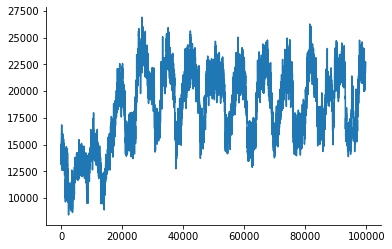

In [38]:
fig,ax=plt.subplots()

ax.plot(X[:,5])

<IPython.core.display.Javascript object>


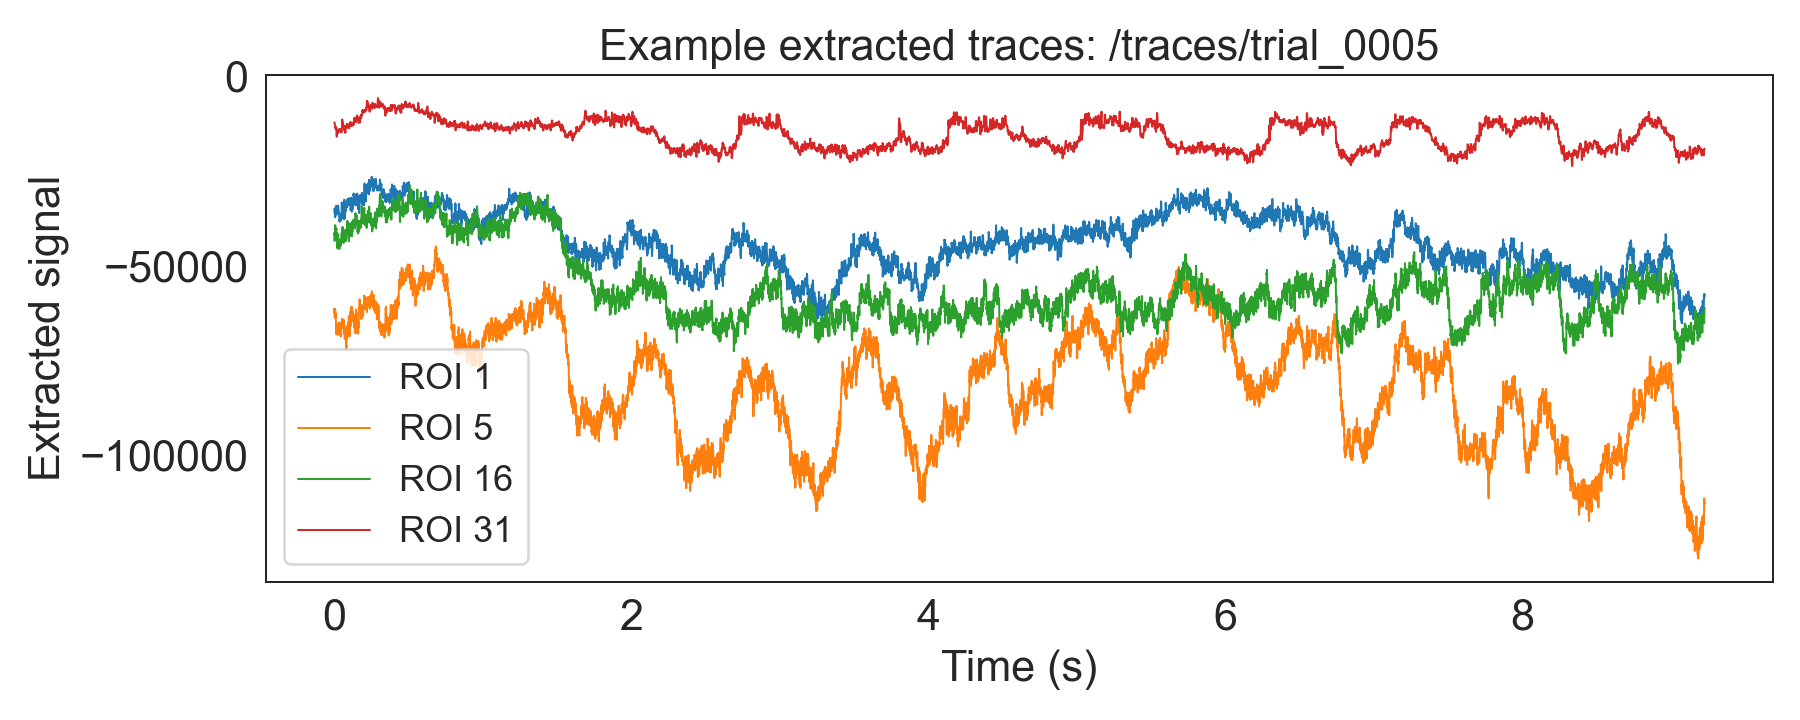

In [56]:
# Choose a few ROI columns to plot.
n_rois = X.shape[1]
roi_cols_1based = [1]
if n_rois >= 5:
    roi_cols_1based.append(5)
if n_rois >= 16:
    roi_cols_1based.append(16)  # first DMD2 ROI for your 15+16 ROI example
if n_rois >= 31:
    roi_cols_1based.append(31)
roi_cols_1based = sorted(set([r for r in roi_cols_1based if 1 <= r <= n_rois]))
roi_cols = [r - 1 for r in roi_cols_1based]

X_plot, stride = downsample_rows_for_plot(X[:, roi_cols], max_points=len(X[:,1]))
x_axis = (np.arange(X_plot.shape[0]) * stride)/10.8e3

plt.figure(figsize=(10, 4))
for i, roi in enumerate(roi_cols_1based):
    plt.plot(x_axis, -X_plot[:, i], lw=0.8, label=f"ROI {roi}")
plt.xlabel("Time (s)")
plt.ylabel("Extracted signal")
plt.title(f"Example extracted traces: {qc_dataset}")
plt.legend(loc="best")
plt.tight_layout()


In [48]:
len(X[:,1])

99670

In [19]:
roi_cols_1based

[1, 5, 16, 31]

## 7. Plot z-scored heatmap across ROIs


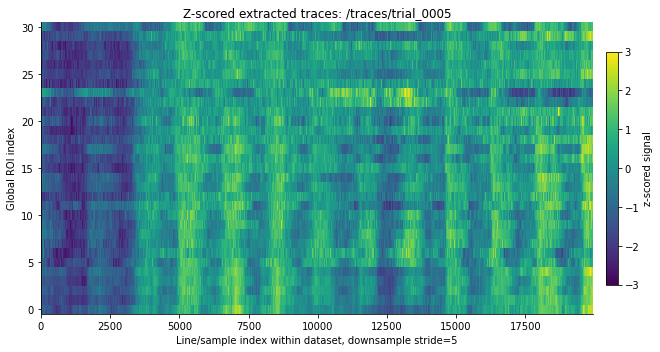

In [40]:
Xz = zscore_by_column(X)
Xz_plot, stride = downsample_rows_for_plot(Xz, max_points=20_000)

plt.figure(figsize=(10, 5))
plt.imshow(
    Xz_plot.T,
    aspect="auto",
    interpolation="nearest",
    vmin=-3,
    vmax=3,
    origin="lower",
)
plt.xlabel(f"Line/sample index within dataset, downsample stride={stride}")
plt.ylabel("Global ROI index")
plt.title(f"Z-scored extracted traces: {qc_dataset}")
cb = plt.colorbar(shrink=0.8, pad=0.02)
cb.set_label("z-scored signal")
plt.tight_layout()


## 8. Plot per-ROI NaN fraction and robust signal range


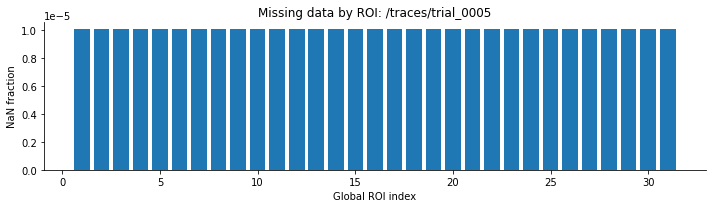

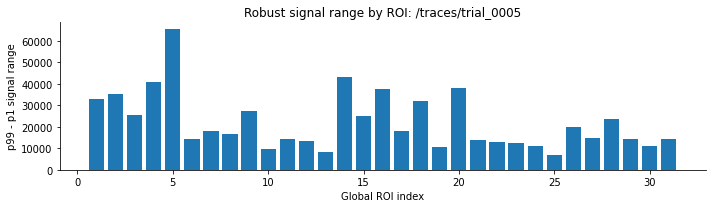

In [41]:
plt.figure(figsize=(10, 3))
plt.bar(qc["global_roi_idx"], qc["nan_fraction"])
plt.xlabel("Global ROI index")
plt.ylabel("NaN fraction")
plt.title(f"Missing data by ROI: {qc_dataset}")
plt.tight_layout()

plt.figure(figsize=(10, 3))
plt.bar(qc["global_roi_idx"], qc["robust_range_p99_p1"])
plt.xlabel("Global ROI index")
plt.ylabel("p99 - p1 signal range")
plt.title(f"Robust signal range by ROI: {qc_dataset}")
plt.tight_layout()


## 9. Check trial lengths across the session


,dataset,n_lines,n_rois,dtype,trialIdx,description
0,/traces/trial_0001,31,99670,float32,[1.0],Trial-sliced traces. Columns are global ROI in...
1,/traces/trial_0002,31,99670,float32,[2.0],Trial-sliced traces. Columns are global ROI in...
2,/traces/trial_0003,31,99670,float32,[3.0],Trial-sliced traces. Columns are global ROI in...
3,/traces/trial_0004,31,99670,float32,[4.0],Trial-sliced traces. Columns are global ROI in...
4,/traces/trial_0005,31,99670,float32,[5.0],Trial-sliced traces. Columns are global ROI in...


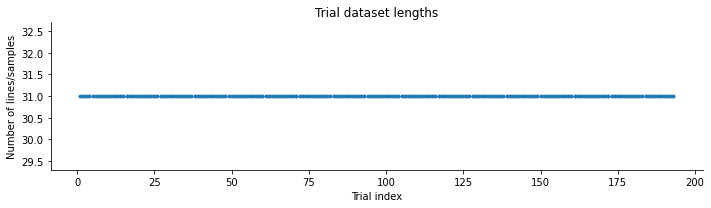

In [42]:
if trial_paths:
    all_trial_dims = dataset_shape_table(h5_path, trial_paths)
    display(all_trial_dims.head())

    plt.figure(figsize=(10, 3))
    plt.plot(np.arange(1, len(all_trial_dims) + 1), all_trial_dims["n_lines"], marker=".", lw=0.8)
    plt.xlabel("Trial index")
    plt.ylabel("Number of lines/samples")
    plt.title("Trial dataset lengths")
    plt.tight_layout()
else:
    print("No trial datasets found; skipping trial-length plot.")


## 10. Optional: plot reference and mask images from the summary

This only works if the MATLAB summary was loaded successfully with `scipy.io.loadmat` or `mat73` and the fields are in a Python-friendly shape.


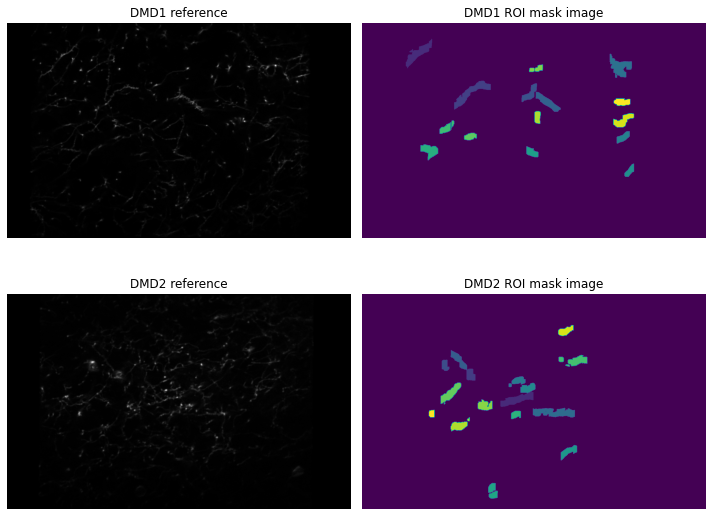

In [43]:
refIM = get_summary_value(summary, "refIM", None)
maskImages = get_summary_value(summary, "maskImages", None)

if refIM is None or maskImages is None:
    print("refIM/maskImages not available. This is common if the summary was saved as MATLAB -v7.3 and mat73 is not installed.")
else:
    # Try to infer number of DMDs from summary or from the cell/list lengths.
    n_dmds_raw = get_summary_value(summary, "nDMDs", None)
    n_dmds = int(np.asarray(n_dmds_raw).squeeze()) if n_dmds_raw is not None else 2
    n_dmds = max(n_dmds, 1)

    fig, axes = plt.subplots(n_dmds, 2, figsize=(10, 4 * n_dmds), squeeze=False)
    for dmd_idx in range(n_dmds):
        ref = get_cell_item(refIM, dmd_idx)
        mask = get_cell_item(maskImages, dmd_idx)

        ax = axes[dmd_idx, 0]
        if ref is not None:
            ax.imshow(np.asarray(ref), cmap="gray")
        ax.set_title(f"DMD{dmd_idx + 1} reference")
        ax.axis("off")

        ax = axes[dmd_idx, 1]
        if mask is not None:
            ax.imshow(np.asarray(mask), cmap="viridis")
        ax.set_title(f"DMD{dmd_idx + 1} ROI mask image")
        ax.axis("off")

    plt.tight_layout()


## 11. Optional: read a short continuous segment

If you ran `params.outputMode = 'continuous'` or `'both'`, this cell reads only the first `n_rows_to_read` lines from each continuous DMD dataset to avoid loading the full recording into memory.


In [44]:
n_rows_to_read = 50_000

if continuous_paths:
    for path in continuous_paths:
        with h5py.File(h5_path, "r") as f:
            d = f[path]
            n = min(n_rows_to_read, d.shape[0])
            Xc = d[:n, :]
        print(f"{path}: read {Xc.shape[0]} rows x {Xc.shape[1]} ROIs")

        Xc_z = zscore_by_column(Xc)
        plt.figure(figsize=(10, 4))
        plt.imshow(Xc_z.T, aspect="auto", interpolation="nearest", vmin=-3, vmax=3, origin="lower")
        plt.xlabel("Line/sample index")
        plt.ylabel("Local ROI index")
        plt.title(f"Continuous preview: {path}")
        cb = plt.colorbar(shrink=0.8, pad=0.02)
        cb.set_label("z-scored signal")
        plt.tight_layout()
else:
    print("No continuous datasets found. This is expected for params.outputMode = 'trial'.")


No continuous datasets found. This is expected for params.outputMode = 'trial'.


## Interpretation checklist

A successful extraction should usually show:

- `summary.complete == 1` in MATLAB, or all extraction statuses marked complete.
- Trial datasets with the expected number of ROI columns.
- Low NaN fraction per ROI.
- Non-flat robust signal ranges across ROIs.
- Example traces with plausible temporal structure rather than all-NaN, all-zero, or huge discontinuous artifacts.
- Trial lengths that match the trial table line ranges.

This notebook only QC-checks extracted ROI traces. It does not perform voltage preprocessing such as bleaching correction, motion regression, spike detection, or ΔF/F normalization.
